# iscc simulation test
End-to-end smoke test: grow a tumor, apply chemotherapy, inspect outputs.

In [1]:
import sys
sys.path.insert(0, '../src')

import iscc
from iscc.constants import normal_names, normal_cmap_rgba
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

CONFIG = '../src/iscc/tumor/tumorconfigs/glandular.yaml'

## 1. Tumor growth (no treatment)

In [2]:
n_steps_total = 500
n_checkpoints = 5
steps_per_chunk = n_steps_total // n_checkpoints

tumor = iscc.tumor.models.GlandularTumor(config=CONFIG)
snapshots = []

for i in range(n_checkpoints):
    tumor.grow(n_steps=steps_per_chunk)
    snapshots.append(tumor.copy())

print(f"Step: {tumor.step}")
print(f"Tumor size: {tumor.get_tumor_size()}")
pd.DataFrame(tumor.genotypes_counts, index=[0])


  0%|          | 0/99 [00:00<?, ?it/s]


  9%|▉         | 9/99 [00:00<00:01, 79.21it/s]


 17%|█▋        | 17/99 [00:00<00:01, 79.02it/s]


 36%|███▋      | 36/99 [00:00<00:00, 126.05it/s]


 63%|██████▎   | 62/99 [00:00<00:00, 175.80it/s]

...


 53%|█████▎    | 52/99 [00:00<00:00, 255.23it/s]


 80%|███████▉  | 79/99 [00:00<00:00, 257.60it/s]


100%|██████████| 99/99 [00:00<00:00, 255.19it/s]

Step: 500
Tumor size: 2995


,stromal,epithelial,5609377936,4622597568
0,2475,24,379,117


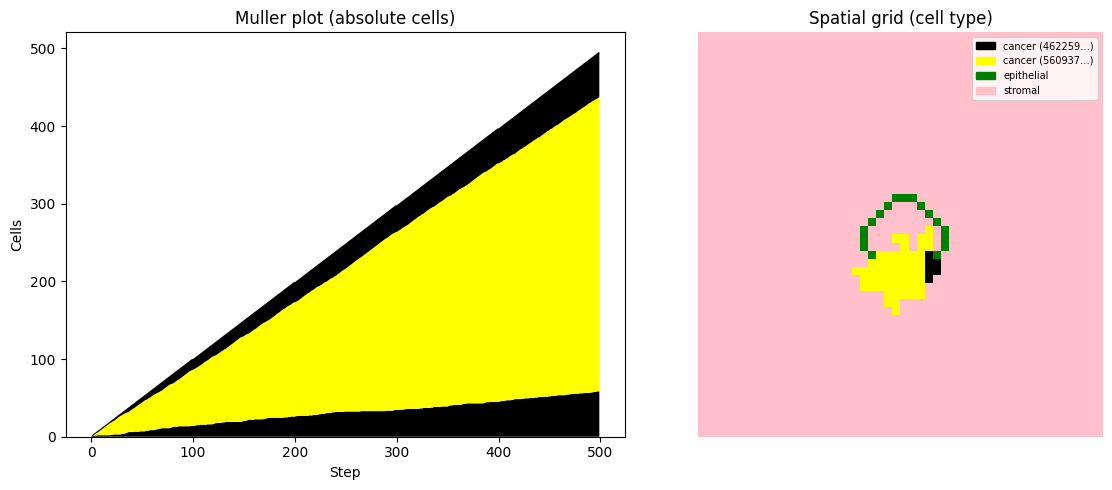

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tumor.plot_muller(ax=axes[0], normalize=False)
axes[0].set_title('Muller plot (absolute cells)')
tumor.plot_grid(ax=axes[1])
axes[1].set_title('Spatial grid (cell type)')
plt.tight_layout()
plt.show()

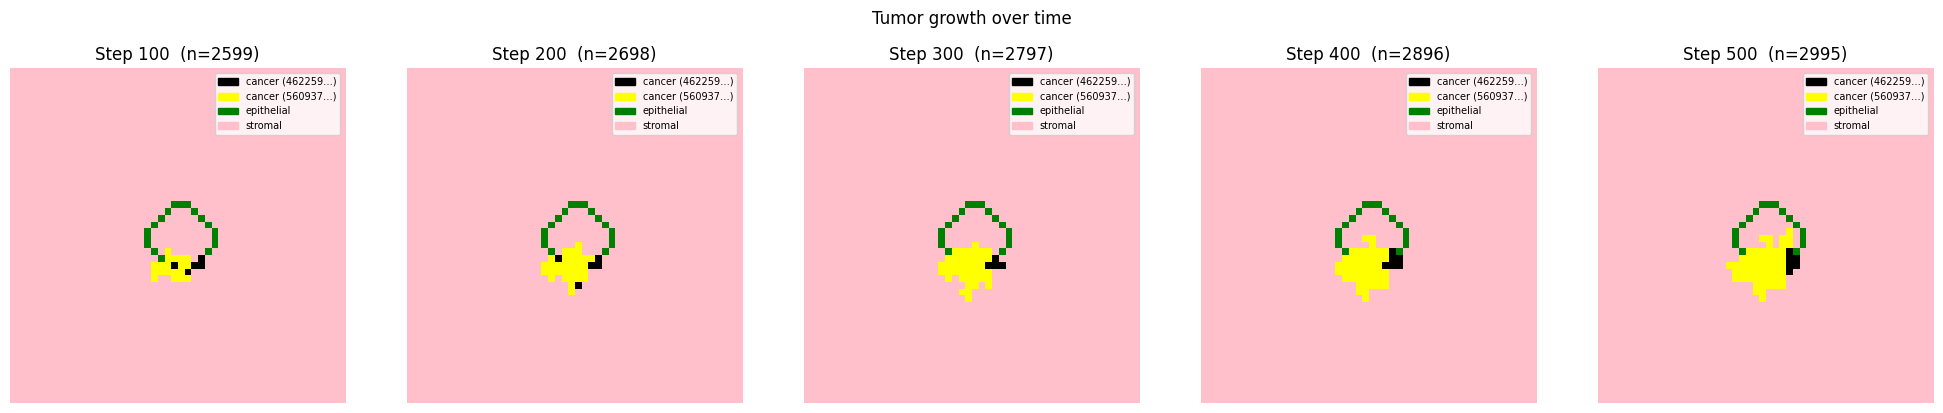

In [4]:
fig, axes = plt.subplots(1, n_checkpoints, figsize=(4 * n_checkpoints, 4))
for snap, ax in zip(snapshots, axes):
    snap.plot_grid(ax=ax)
    ax.set_title(f'Step {snap.step}  (n={snap.get_tumor_size()})')
plt.suptitle('Tumor growth over time', y=1.02)
plt.tight_layout()
plt.show()

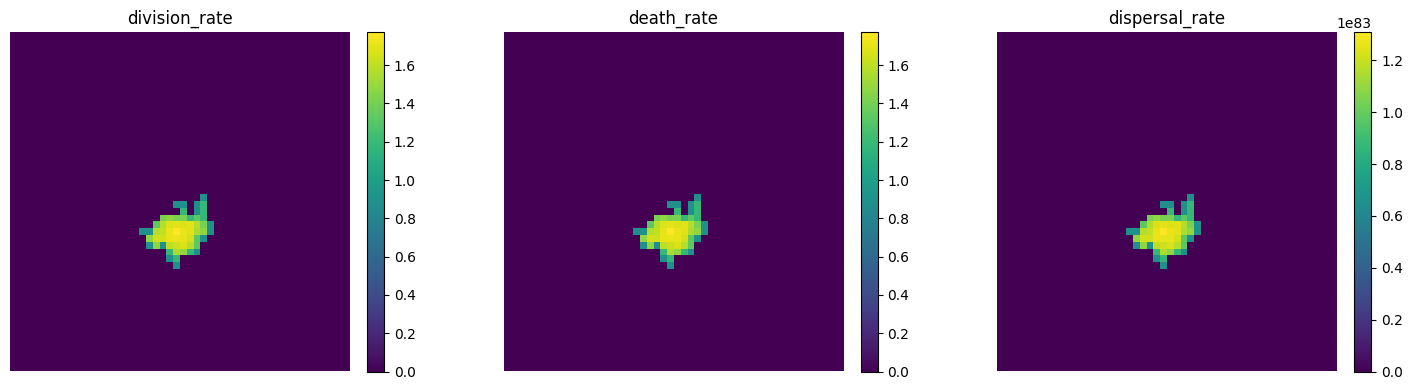

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, param in zip(axes, ['division_rate', 'death_rate', 'dispersal_rate']):
    tumor.plot_grid(color=[param], ax=ax)
    ax.set_title(param)
plt.tight_layout()
plt.show()

## 2. Clone characterization

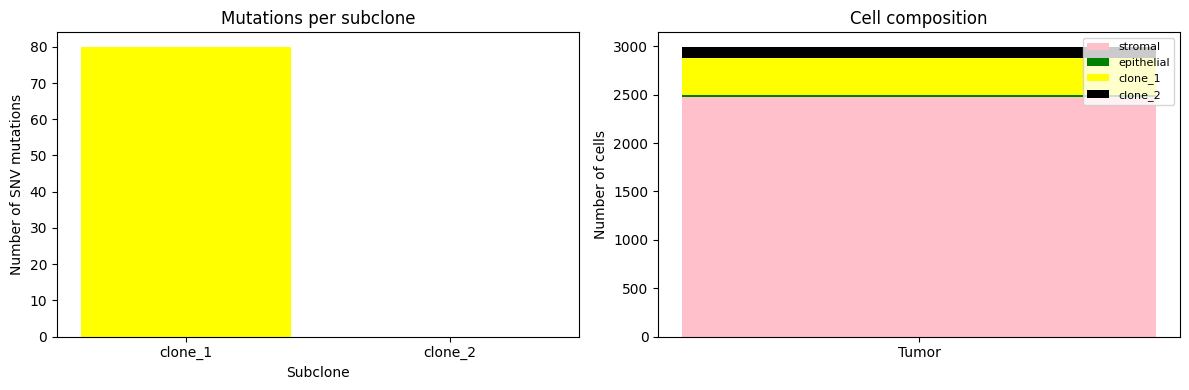

In [6]:
cell_type_df = tumor.cell_data['cell_type']
cell_snv_df  = tumor.cell_data['cell_snv']

cancer_clone_ids = [gid for gid in cell_type_df['cell_id'].unique() if gid not in normal_names]
type_cmap = tumor.get_cell_type_colors()
short_labels = [f'clone_{i+1}' for i in range(len(cancer_clone_ids))]
colors = [type_cmap.get(gid, [0.5, 0.5, 0.5, 1.0]) for gid in cancer_clone_ids]

# Mutations per subclone: one representative cell per clone, count mutated positions
clone_n_muts = {}
for clone_id in cancer_clone_ids:
    rep = cell_type_df[cell_type_df['cell_id'] == clone_id].index[0]
    clone_n_muts[clone_id] = int((cell_snv_df.loc[rep] > 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: mutations per subclone
axes[0].bar(short_labels, [clone_n_muts[gid] for gid in cancer_clone_ids], color=colors)
axes[0].set_xlabel('Subclone')
axes[0].set_ylabel('Number of SNV mutations')
axes[0].set_title('Mutations per subclone')

# Stacked bar: cell composition
bottom = 0
for cell_type_name in ['stromal', 'epithelial', 'immune']:
    count = tumor.genotypes_counts.get(cell_type_name, 0)
    if count > 0:
        axes[1].bar(['Tumor'], count, bottom=bottom,
                    color=normal_cmap_rgba[cell_type_name], label=cell_type_name)
        bottom += count

for clone_id, label, color in zip(cancer_clone_ids, short_labels, colors):
    count = tumor.genotypes_counts[clone_id]
    axes[1].bar(['Tumor'], count, bottom=bottom, color=color, label=label)
    bottom += count

axes[1].set_ylabel('Number of cells')
axes[1].set_title('Cell composition')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### Gene mutation status and expression

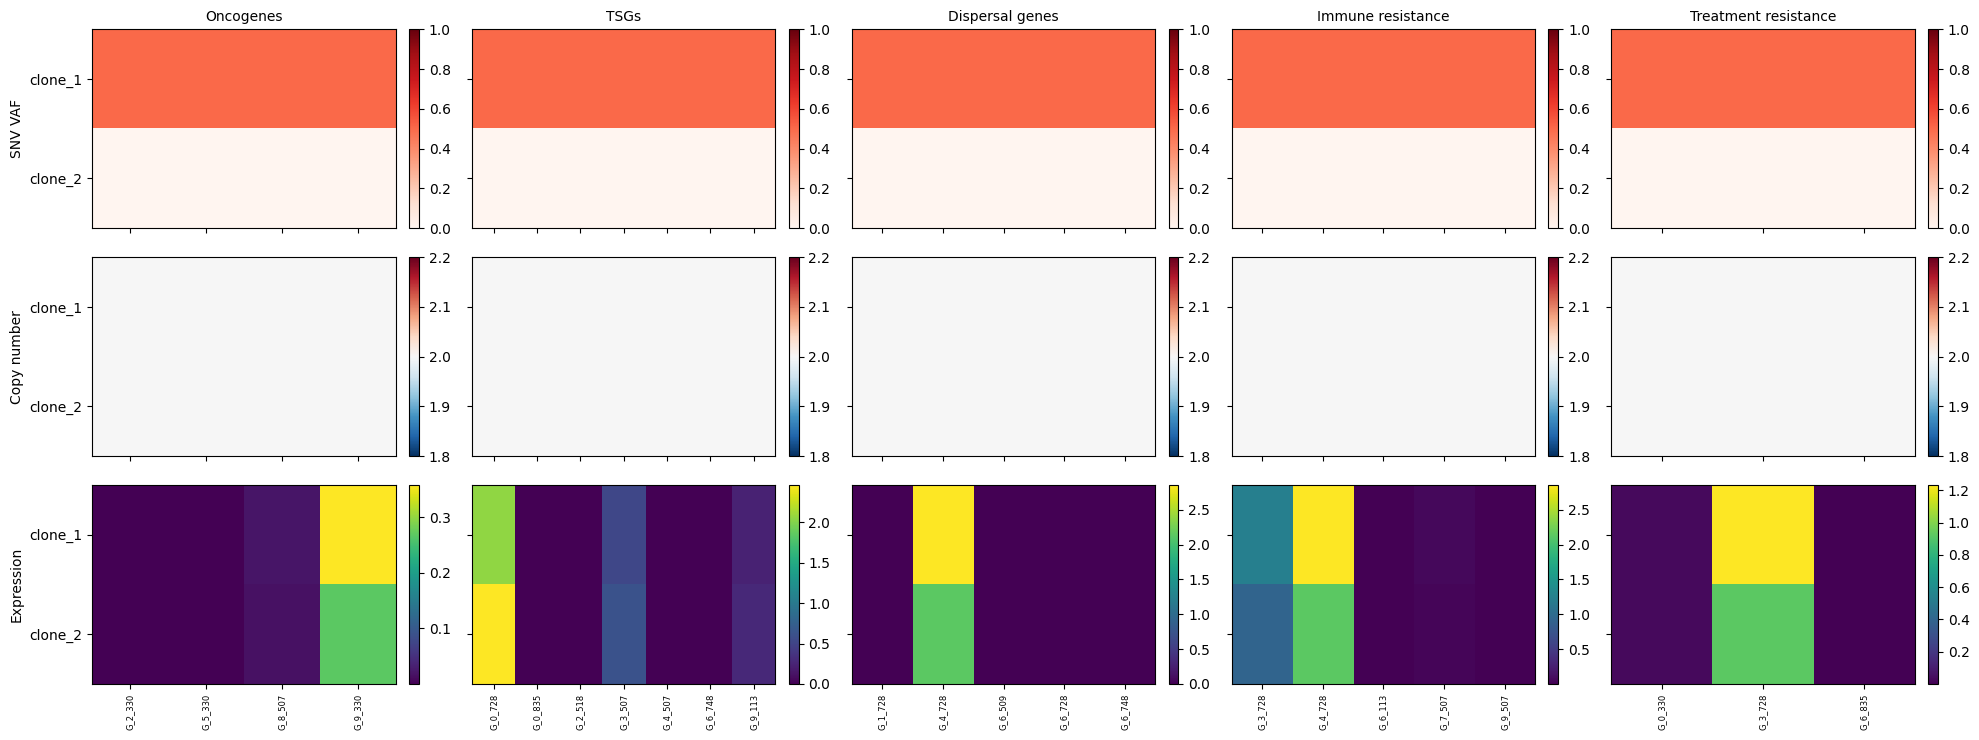

In [7]:
gene_names = tumor.selection.get_gene_names()

categories = {
    'Oncogenes':            tumor.selection.get_oncogenes(),
    'TSGs':                 tumor.selection.get_tsgs(),
    'Dispersal genes':      tumor.selection.get_dispersal_genes(),
    'Immune resistance':    tumor.selection.get_immune_resistant(),
    'Treatment resistance': tumor.selection.get_treatment_resistant(),
}

modalities = [
    ('SNV VAF',     'cell_snv', 'Reds',    0,    1),
    ('Copy number', 'cell_cnv', 'RdBu_r',  None, None),
    ('Expression',  'cell_exp', 'viridis', None, None),
]

cell_type_df = tumor.cell_data['cell_type']
cancer_clone_ids = [gid for gid in cell_type_df['cell_id'].unique() if gid not in normal_names]
clone_labels = [f'clone_{i+1}' for i in range(len(cancer_clone_ids))]
rep_idx = [cell_type_df[cell_type_df['cell_id'] == cid].index[0] for cid in cancer_clone_ids]
rep_snv = tumor.cell_data['cell_snv'].loc[rep_idx]

n_rows = len(modalities)
n_cols = len(categories)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4 * n_cols, 2.5 * n_rows),
                          sharex='col', sharey=True)

for col_idx, (cat_name, gene_idx) in enumerate(categories.items()):
    cat_genes = [gene_names[i] for i in gene_idx]
    display_genes = [g for g in cat_genes if rep_snv[g].max() > 0]
    if not display_genes:
        display_genes = cat_genes[:30]

    for row_idx, (mod_name, data_key, cmap, vmin, vmax) in enumerate(modalities):
        ax = axes[row_idx, col_idx]
        arr = tumor.cell_data[data_key].loc[rep_idx, display_genes].values
        im = ax.imshow(arr, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Column header on top row
        if row_idx == 0:
            ax.set_title(cat_name, fontsize=10)

        # Row label on leftmost column
        if col_idx == 0:
            ax.set_ylabel(mod_name)
            ax.set_yticks(range(len(clone_labels)))
            ax.set_yticklabels(clone_labels)

        # Gene labels on bottom row
        ax.set_xticks(range(len(display_genes)))
        if row_idx == n_rows - 1:
            ax.set_xticklabels(display_genes, rotation=90, fontsize=6)
        else:
            ax.set_xticklabels([])

plt.tight_layout()
plt.show()

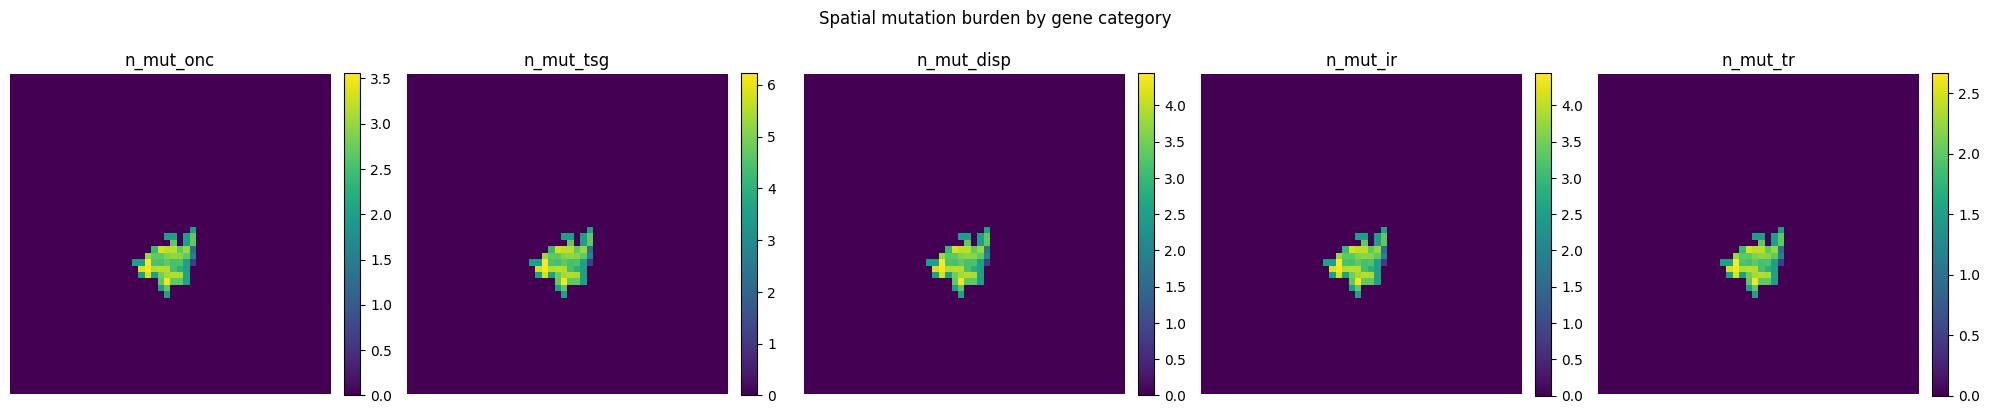

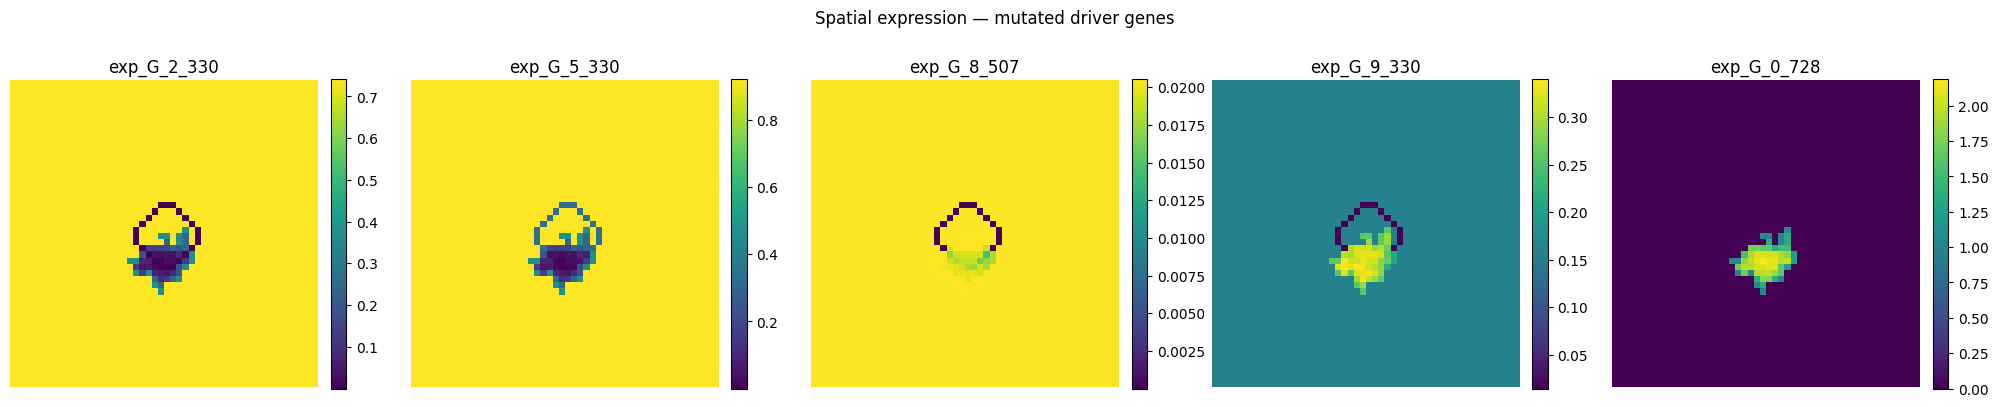

In [8]:
gene_names = tumor.selection.get_gene_names()

# Spatial mutation burden per gene category
mut_cols = ['n_mut_onc', 'n_mut_tsg', 'n_mut_disp', 'n_mut_ir', 'n_mut_tr']
fig, axes = plt.subplots(1, len(mut_cols), figsize=(4 * len(mut_cols), 4))
for ax, col in zip(axes, mut_cols):
    tumor.plot_grid(color=[col], ax=ax)
plt.suptitle('Spatial mutation burden by gene category', y=1.02)
plt.tight_layout()
plt.show()

# Spatial expression of a few mutated driver genes
all_driver_genes = [gene_names[i] for i in list(tumor.selection.get_oncogenes()) + list(tumor.selection.get_tsgs())]
display_genes = [g for g in all_driver_genes if tumor.cell_data['cell_snv'][g].max() > 0][:5]
if not display_genes:
    display_genes = all_driver_genes[:5]

fig, axes = plt.subplots(1, len(display_genes), figsize=(4 * len(display_genes), 4))
if len(display_genes) == 1:
    axes = [axes]
for ax, gene in zip(axes, display_genes):
    tumor.plot_grid(color=[f'exp_{gene}'], ax=ax)
plt.suptitle('Spatial expression — mutated driver genes', y=1.02)
plt.tight_layout()
plt.show()

## 3. MDT chemotherapy (maximum tolerated dose)
Copy the grown tumor and apply chemo for 200 steps starting immediately.

In [9]:
tumor_mdt = tumor.copy()

mdt_chemo = iscc.treatment.Chemotherapy(start=tumor_mdt.step, duration=200, adaptive=False)
tumor_mdt.grow(n_steps=300, treatment=mdt_chemo)

print(f"Step: {tumor_mdt.step}, size: {tumor_mdt.get_tumor_size()}")


  0%|          | 0/299 [00:00<?, ?it/s]


  7%|▋         | 22/299 [00:00<00:01, 218.72it/s]


 15%|█▍        | 44/299 [00:00<00:01, 219.06it/s]


 23%|██▎       | 69/299 [00:00<00:00, 232.67it/s]


 32%|███▏      | 95/299 [00:00<00:00, 243.08it/s]

...


 82%|████████▏ | 244/299 [00:01<00:00, 236.19it/s]


 90%|████████▉ | 268/299 [00:01<00:00, 232.30it/s]


 98%|█████████▊| 292/299 [00:01<00:00, 231.64it/s]


100%|██████████| 299/299 [00:01<00:00, 235.25it/s]

Step: 800, size: 3294


/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_33506/3173747204.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


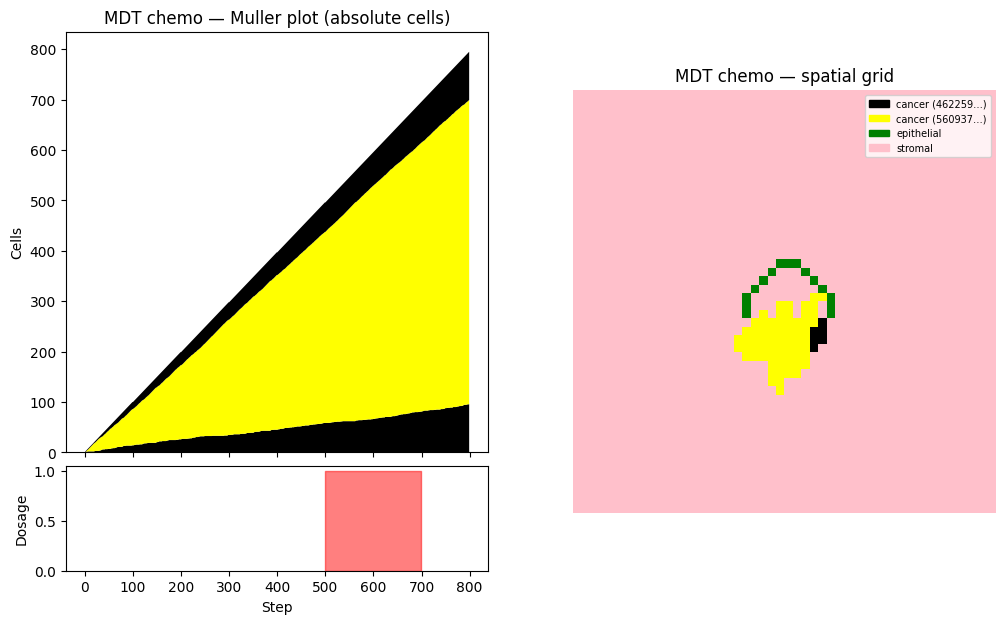

In [10]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[4, 1], hspace=0.05)
ax_muller = fig.add_subplot(gs[0, 0])
ax_dosage = fig.add_subplot(gs[1, 0], sharex=ax_muller)
ax_grid   = fig.add_subplot(gs[:, 1])

tumor_mdt.plot_muller(ax=ax_muller, normalize=False)
ax_muller.set_title('MDT chemo — Muller plot (absolute cells)')
ax_muller.set_xlabel('')
plt.setp(ax_muller.get_xticklabels(), visible=False)

steps, dosages = zip(*mdt_chemo.dosage_trace)
ax_dosage.fill_between(steps, dosages, alpha=0.5, color='red', step='post')
ax_dosage.set_ylabel('Dosage')
ax_dosage.set_ylim(bottom=0)
ax_dosage.set_xlabel('Step')

tumor_mdt.plot_grid(ax=ax_grid)
ax_grid.set_title('MDT chemo — spatial grid')

plt.tight_layout()
plt.show()

## 4. Adaptive chemotherapy
Only applies treatment when tumor exceeds a size threshold.

In [11]:
tumor_adaptive = tumor.copy()

adaptive_chemo = iscc.treatment.Chemotherapy(
    adaptive=True,
    start=tumor_adaptive.step,
    max_tumor_size=tumor_adaptive.get_tumor_size(),  # treat whenever tumor grows beyond current size
)
tumor_adaptive.grow(n_steps=300, treatment=adaptive_chemo)

print(f"Step: {tumor_adaptive.step}, size: {tumor_adaptive.get_tumor_size()}")


  0%|          | 0/299 [00:00<?, ?it/s]


  8%|▊         | 24/299 [00:00<00:01, 232.79it/s]


 17%|█▋        | 50/299 [00:00<00:01, 248.57it/s]


 25%|██▌       | 75/299 [00:00<00:00, 248.33it/s]


 34%|███▍      | 102/299 [00:00<00:00, 254.26it/s]

...


 81%|████████  | 241/299 [00:00<00:00, 259.79it/s]


 90%|████████▉ | 268/299 [00:01<00:00, 243.93it/s]


 98%|█████████▊| 293/299 [00:01<00:00, 240.35it/s]


100%|██████████| 299/299 [00:01<00:00, 251.57it/s]

Step: 800, size: 3294


/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_33506/1835438407.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


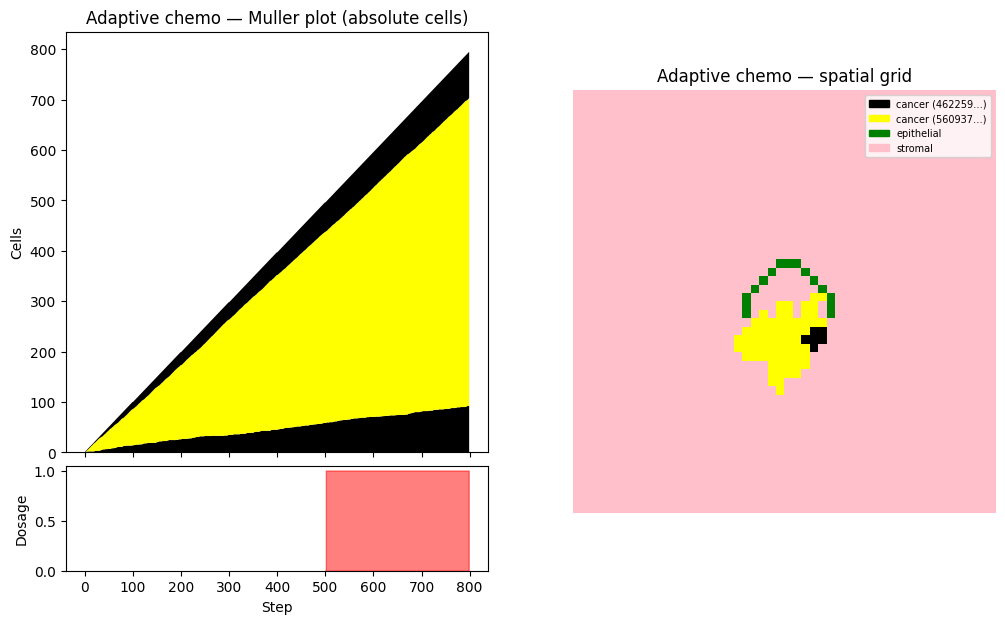

In [12]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[4, 1], hspace=0.05)
ax_muller = fig.add_subplot(gs[0, 0])
ax_dosage = fig.add_subplot(gs[1, 0], sharex=ax_muller)
ax_grid   = fig.add_subplot(gs[:, 1])

tumor_adaptive.plot_muller(ax=ax_muller, normalize=False)
ax_muller.set_title('Adaptive chemo — Muller plot (absolute cells)')
ax_muller.set_xlabel('')
plt.setp(ax_muller.get_xticklabels(), visible=False)

steps, dosages = zip(*adaptive_chemo.dosage_trace)
ax_dosage.fill_between(steps, dosages, alpha=0.5, color='red', step='post')
ax_dosage.set_ylabel('Dosage')
ax_dosage.set_ylim(bottom=0)
ax_dosage.set_xlabel('Step')

tumor_adaptive.plot_grid(ax=ax_grid)
ax_grid.set_title('Adaptive chemo — spatial grid')

plt.tight_layout()
plt.show()